# Предподготовка данных и исследовательский анализ данных.
---
Предподготовка данных и исследовательский анализ данных. Визуализация образовательных данных.

(лекция 2 часа, практика 4 часа)

- Признаковое описание объектов. Виды признаков. Типы данных.

- Задачи предподготовки данных для последующего анализа: заполнение пропущенных данных, преобразование типов даннных, удаление дубликатов, некорректных данных.

- Данные с образовательных порталов. Обеспечение защиты персональных данных. Обезличивание данных.

- Исследовательский анализ данных. Задачи и методы.

- Предобработка данных

## **1. Признаковое описание объектов**
---
Анализ данных подразумевает исследование закономерностей совокупности объектов. Описание одного объекта мало что дает. Закономерности, инварианты можно выделить изучая большие множества объектов. Чтобы изучать объекты надо получить их описание. Рассмотрим основную модель данных, исползуемую в анализе и в машинном обучении.

Будем считать, что у нас имеется

- имеется конечное или бесконечное множество $O$ изучаемых однородных объектов (объекты реального мира/учащиеся/процессы);

- имеется набор значений признаков - параметров, описывающих эти объекты; значения признаков для каждого объекта мы получаем в результаты наблюдений;

- т.е. для каждого объекта из некоторого множества мы можем получить в результате наблюдения их информационные описания
$$\overline{x}^{(k)} = \left(x^{(k)}_1, x^{(k)}_2, ..., x^{(k)}_n \right), k=1,..,K$$
в виде векторов значений $n$ признаков, их характеризующих;

Таким образом, у нас есть множество описаний объектов, которые можно свести в таблицу, где каждая строка соответствует объекту, а каждый стоблец - признаку, описывающему объект.

Одному объекту может соответствовать разные признаковые описания. Аналитики стремятся получить такое признаковое описание, которое позволит лучше решить поставленную перед ними задачу.

### ПРИМЕР 2.1
---
Чаще всего для нас объекты будут соответствовать обучающимся, а признаки - это характеристики, описывающие этих учащихся, например, ФИО, группа, курс, средний балл, или баллы, полученные за задания курса. Тогда строка таблицы X будет соответствовать обучающемуся, а столбец - признаку описания учащегося.

### **Виды признаков, описывающих объекты**
Обозначим множество возможных значений i-го признака $f_i$ через $D_i$.
Тогда
- $f_i$ - бинарный признак, если $|D_i|=2; \; (D_i = \{ 0, 1 \}; \; D_i = \{ М, Ж \}; \; D_i = \{ True, False \})$;
- $f_i$ - номинальный или категориальный признак, если $D_i$ - перечислимое множество неупорядоченных значений ($D_i$ = {Иванов, Сидоров, Петров, ...});
- $f_i$ - порядковый признак, если $D_i$ - перечислимое множество упорядоченных значений ($D_i$=(среднее, бакалавр, магистр));
- $f_i$ - количественный признак, если $D_i = R$ (числа);

Для решения задач анализа данных и машинного обучения все виды признаков мы будем приводить к числовым признакам. Но способы приведения зависят от вида признака и специфики задачи.

Если мы объединим все числовые описания объектов в одной матрице **X**, каждая строка которой содержит описание какого-то одного объекта, то мы получим объектно-признаковую матрицу. Число строк данной матрицы совпадает с числом описываемых матрицей объектов, а число столбцов совпадает с числом признаков, с помощью которых мы описываем эти объекты.

### Типы данных.
---

Значения признаков выражаются в конкретных данных. Основные типы данных, с помощью которых мы будем выражаит зрачения признаков следующие:

- строка (**str, object**), содержит данные в текстовом виде; может содержать слово или большой текст, описание объекта; используется для описания значений категориальных и порядковых признаков; это самый общий тип данный, который нам придется кодировать числами.

- целое число (**int**); используется для кодирования значений категориальных и порядковых признаков;

- вещественнное число (**float**); самый полезный тип данных для анализа;

- булевое значение (**bool**), принимает только два возможных значения (True, False); удобный тип для кодирования бинарных признаков, легко сводится к целому типу (true = 1, False = 0);

- **NoneType**, тип в Python, имеет только одно значение **None** поезен для того, чтобы кодировать пропущенные,отсутствующие значения признаков.


### ПРИМЕР таблицы исходных данных
---

In [ ]:
# импорт необходимых библиотек работы с данными
import numpy as np
np.set_printoptions(precision=3)
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# подключение гугл-диска к среде colab
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# DIR PATH to DATA
dir_path = "/content/drive/My Drive/Colab Notebooks/teacher/EducationDA/data/"

# Чтение данных из файла *.xlsx
file_name = "LinAlg-2.xlsx"
file_path = dir_path + file_name
df = pd.read_excel(file_path)
print(df.shape)

In [ ]:
df.sample(10)

## **2. Задачи предподготовки данных**
---

В подавляющем большинстве случаев, после того, как вы собрали данные, вам нужно будет их подготовить, прежде чем вы сможете их использовать. Анализа данных - это один из этапов решения задач на сонове данных.

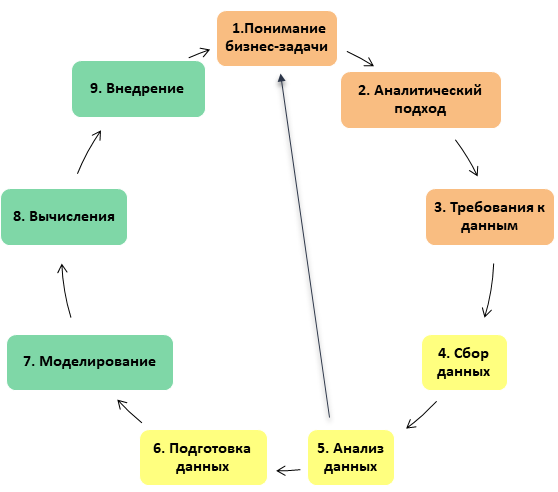

Рис.1. Цикл построения моделей, основанных на данных: результатом анализа данных может стать необходимость вернуться к корретировке задачи или добавление требований сбора дополнительных данных

Сам анализ данных также включает множество этапов.

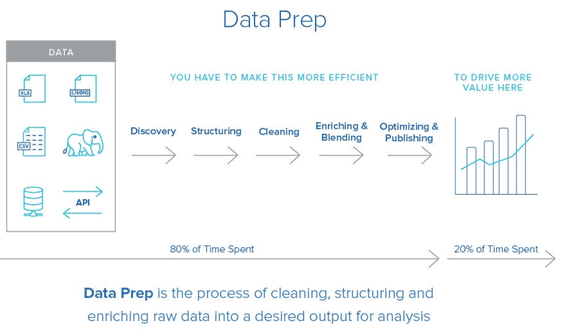

Data Preparation – весьма трудоемкий итеративный процесс, который занимает до 80\% всех затрат ресурсов и времени в жизненном цикле моделирования или машинного обучения (см. рис. 2) и включает следующие задачи обработки исходных («сырых») данных:

-  **Очистка данных** – удаление опечаток, некорректных значений (например, число в строковом параметре и пр.), отсутствующих значений (Missing values или NA), исключение дублей и разных описаний одного и того же объекта, восстановление уникальности, целостности и логических связей;

- **Кодирование данных** – представление признаков в нужном формате с учетом целей машинного обучения - например, текстовые или категориальные признаки кодируются целыми числами, непрерывные переменные дискретизируются, ...;

- **Преобразование данных**: нормализация данных для уменьшения размеров и шума.

- **Форматирование данных** – синтаксические изменения, которые не меняют значение данных, но требуются для инструментов моделирования, например, сортировка в определенном порядке или удаление ненужных знаков препинания в текстовых полях, обрезка «длинных» слов, округление вещественных чисел до целого и т.д.

- **Интеграция данных** – слияние данных из различных источников (информационных систем, таблиц, протоколов и пр.), включая их агрегацию, когда новые значения вычисляются путем суммирования информации из множества существующих записей;


## **3. Данные с образовательных порталов**.
---
Обеспечение защиты персональных данных. Обезличивание данных.

Электронное обучение, онлайн-обучение во всем мире набирает обороты. Любое серьезное образовательное учреждение использует образовательные порталы для организации обучения. И не только в университетах, сейчас мало-мальски продвинутые школы также используют онлайн-среды и порталы для выдачи заданий ученикам и сбора информации о результатах обучения.

ПОэтому образовательные порталы - это платформы, на которых собирается огромное количество информации, касающейся процедуры и результатов обучения.

Рассмотрим способы представления информации с образовательных порталов и возможные задачи предподготовки данных, которые могут возникнуть при использовании этой информации в реальной жизни на примере компании iSpring.


### Кейс компании iSpring
---
Современная корпорация понимает, что без постоянного обучения своих сотрудников компания не сможет динамично развиваться и реагировать на вызовы современности.

Как реализовать постоянное обучение без отрыва от работы? Конечно, это онлайн-обучение. И не просто онлайн-обучение. А система обучения, со своим расписанием, с картой компетенций на каждого работника и с анализом того, кому какое обучение необходимо пройти и в какие сроки.

В этой связи компания iSpring, которая специализируется на организации онлайн-обучения и имеет такие продвинутые продукты как iSpring Suite и iSpring СДО, разработала систему корпоративного обучения, в которой планируется и регистрируются результаты обучения всех сотрудников компании, создаются их компетентностные карты.

В этих системах накапливается большая статистика прохождения обучения работниками. Закономерным следующим шагом является попытка использовать эту статистику для решения важных вопросов кадровой политики и развития компании. Например, компании хотели бы получить ответы на такие вопросы:

- какие обучающие мероприятия способствуют повышению активности работников, воспринимаются ими как полезные для повышения эффективности их работы?

- какие обучающие мероприятия, курсы сложны для обучения, вызывают затруднения, а какие хорошо выстроены;

- насколько сложно пройти те или иные асинхронные онлайн-курсы и сколько времени это в среднем отнимает у обучающихся?

- можно ли по тому, насколько активно работник участвует в корпоративном обучении, по его результатам обучения, классифицировать их по степени выгорания, пытаться спрогнозировать его дальнейший рост или деградацию?

### Знакомство с данными с образовательных порталов
---

In [ ]:
from os import listdir
from os.path import isfile, join

dir_path = "/content/drive/My Drive/Colab Notebooks/iSpring/data/prod-ru-learner-progress-statistics/"
onlyfiles = [f for f in listdir(dir_path) if isfile(join(dir_path, f))]

Первое, что надо сделать - это загрузить данные и посмотреть на статистику. Мы для примера будем работать только с одним файлом данных, полученного из одного учреждения.

In [ ]:
file_name = 'learner-progress-statistics-32133.csv'
df = pd.read_csv(dir_path + file_name, sep=';', index_col=False, header=0)
df.tail(3)

##

Видим, что эти данные показывают:

- **количество записей** равно 12861 (нумерация от 0 до 12860);
- **learner\_id**: обезличенный идентификатор работника компании;
- **course\_id**: идентификатор курса, на котором он проходил обучение;
- **enrollment\_id**: идентификатор самой записи зачисления слушателя на курс;
- **course\_type** - тип курса;

и ряд других параметров, характеризующих параметры и результаты прохождения данного курса данным слушателем;

набор дат:

- **access_date** - дата, начиная с которой курс доступен учащемуся, \\
- **due_date**    - дата к которой нужно пройти курс, \\
- **expiration_date**  - дата, после которой доступ к курсу блокируется (равно due_date либо отсутствует), \\
- **completion_date**  - дата завершения курса пользователем,

числовые признаки
- **views_count** - количество просмотров курса,
- **completion_score** - количество набранных баллов,
- **passing_score** - количество баллов, которое надо набрать для завершения курса.

и категориальный признак **text_status_code** - статус прохождения курса.

Также мы видим 1-ю проблему - большое количество неопределенных полей (NaN).

Реальные данные собираются для последующей обработки из разных источников и процессов. Они могут содержать ошибки и повреждения, негативно влияющие на качество набора данных. Вот какими могут быть типичные проблемы с качеством данных:

- **Неполнота**: данные не содержат атрибутов, или в них пропущены значения;

- **Шум**: данные содержат ошибочные записи или выбросы;

- **Несогласованность**: данные содержат конфликтующие между собой записи или расхождения.


### Разведочный анализ данных

Посмотрим сколько данных у нас в этом файле и более детальную информацию о количестве заполненных (not-null) данных по каждому полю:

In [ ]:
df.info() # покажет информацию о размерности данных
          # описание индекса, количество заполненных (not-null) элементов

Видим, что имеется 5 полей float64, 1 поле int64 и 9 полей типа object (дата, время, текстовые и категориальные).

In [ ]:
df.describe() # показывает статистики count,mean, std, min, 25%-50%-75% percentile, max для числовых полей

In [ ]:
df.nunique() # количество уникальных значений для каждого столбца

Из этих данных мы видим, что
- имеются сведения о 1364-х обучающихся на 315 курсах;
- имеется 9 разных типов курсов;
- может быть до 40 просмотров одного курса;
- 6 различных статусов прохождения курса;

и другие интересные факты. Дальнейший разведочный анализ был посвящен детализации этих сведений, анализу распределений по каждому параметру и выявлению статистических зависимостей между параметрами, для того, чтобы убрать коррелирующие паарметры.

На основании далнейшего знакомства с данными были сделаны следующие выводы:

- в исходных CSV файлах находятся обезличенные данные о просмотрах контента пользователями СДО iSpring Learn из аккаунтов разных клиентов.;

- надо подумать о том - как заполнить пропущенный данные - их довольно много;

- Всего для 22\% заданий/курсов установлена дата выполнения; т.е. при анализе прохождение курса слушателем нельзя использовать данный показатель для всех курсов; также далеко не у всех курсов есть порог прохождения в баллах;

- почти 60\% курсов имеют тип "learning\_path", т.е. это электронные курсы с несколькими уроками;

- если у курса нет порога прохождения, то его выполнение фиксируется статусом "Завершен"; все тексты/презентации и другие ресурсы, для которых просто требуется просмотр маркируются статусом "Завершен" при их просмотре;

- если у курса есть порог успешного прохождения, то они могут быть очень разными; большинство настроены на 80%;

- необходимо добавить и закодировать новые (бинарные) признаки и отдельно анализировать поведение обучающихся на заданиях/курсах, не требующих оценки, и отдельно на заданиях, требующих обучения и набора баллов;

Если проанализировать имеющуюся информацию с точки зрения цели - выделения различных классов работников и разных классов курсов, то явно потребуется хорошо подумать как преобразовать и закодировать данную информацию, чтобы она стала полезной для решения данной задачи.

## 4. **Предподготовка данных**
---
прежде чем мы сможем провести более детальный анализ данных, нужно их подготовить: очистить, заполнить пропущенные данные, отфильтровать ненужные признаки, закодировать категориальные и порядковые признаки, отнормировать.

### **4.1. Фильтрация данных**

Для начала удалим столбцы с идентификаторамм пользователей и зачислений, они нам пока не нужны для первичного анализа и столбец "is_manual_modified". он не несет для нас какой-то важной информации.

-----------

In [ ]:
df = df.drop(labels=df.columns[0:3:2], axis=1)
df = df.drop(labels=df.columns[-1], axis=1)
df.tail(3)

Теперь надо подумать как использовать информацию в столбцах дат. Ее надо как-то преобразовать в числовые данные.

Также надо подумать о том - как заполнить пропущенный данные - их довольно много

### **4.2. Преобразование информации**
---


In [ ]:
df.info()

мы видим, что нам сложно будет использовать произнаки - даты (например, чтобы узнать сколько дней прошло от начала обучения до завершения). Таким образом надо перекодировать эти данные из строковых в тип дата. Заодно отфильтруем ненужные для наших целей данные.

Предлагается использовать набор дат

- access_date - дата, начиная с которой курс доступен учащемуся, \ due_date - дата к которой нужно пройти курс, \ expiration_date - дата, после которой доступ к курсу блокируется (равно due_date либо отсутствует), \ completion_date - дата завершения курса пользователем,

- числовые признаки views_count, completion_score, satisfaction_score, passing_score

- и категориальный признак text_status_code

---

In [ ]:
# Посмотрим для скольких заданий установлена дата выполнения due_date
print(df.loc[df.due_date.isna() != True,:].shape)
df.loc[df.due_date.isna() != True,:].head()

In [ ]:
df.loc[df.due_date.isna() != True,:].shape[0] * 100 // df.shape[0]

Всего для 40% заданий установлена дата выполнения.

In [ ]:
df['access_date'] = pd.to_datetime(df['access_date'])
df['due_date'] = pd.to_datetime(df['due_date'])

df.info()

вуаля! теперь можно работать с датами

### **4.3. Обработка пропущенных данных**
---

При работе с пропущенными значениями лучше сначала определить причину их появления в данных, что поможет решить проблему. Вот какие бывает методы обработки пропущенных значений:

- **Удаление**: удаление записей с пропущенными значениями;
- **Фиктивная подстановка** — замена пропущенных значений фиктивными, например подстановка значения unknown; (неизвестно) вместо категориальных или значения 0 вместо чисел;
- **Подстановка среднего значения**: пропущенные числовые данные можно заменить средним значением;
- **Подстановка часто используемого элемента**: пропущенные категориальные значения можно заменить наиболее часто используемым элементом;
- **Подстановка по регрессии**: использование регрессионного метода для замены пропущенных значений регрессионными.

In [ ]:
df.tail(3)

Если вернуться к нашей задаче, то здесь имеет смысл заполнить пропущенные значения только для поля **passing_score**. Его можно заполнить нулями. Это имеет смысл, так как, если это поле не заполнено, то неважно сколько слушатель наберет баллов. Хоть 0.

Остальные поля заполнять не имеет смысла хотя бы потому, что нам нужны новые поля, которые показывают не когда слушатель закончил, а закончил он до срока или после срока, успел ли он завершить курс до его закрытия и т.д. Т.е. нам нужно сгенерировать новые признаки, на основании которых мы будем делать выводы и анализировать курсы и слушателей.

## Исследовательский анализ данных. Задачи и методы.
---


А сейчас мы обратимся к исследованию подготовленных данных, которое осуществляется с помощью простого статистического и графического анализов.

Цель - проанализировать распределение значений как отдельных параметров, так и их взаимовлияние. Понять - какие связи существуют между параметрами. Попытаться понять общую структуру данных. Какие из признаков влияют на целевой признак.


Загрузим более простые и подготовленные данные для анализа.

В качестве исходных данных мы будем использовать обработанные ранее результаты выгрузки журнала оценок с онлайн-курса, который содержит результаты выполнения заданий онлайн-курса слушателями (объектно-признаковая матрица) и их финальные баллы (последний или 1-й столбец).

In [ ]:
# DIR PATH to DATA
dir_path = "/content/drive/My Drive/Colab Notebooks/teacher/INTO DA/3 ExploratoryAnalysis/data/"

course_file_name = "LinAlg-2_tiny.csv"
csv_file_path = dir_path + course_file_name

# Чтение данных из файла
data = pd.read_csv(csv_file_path, sep=';', index_col=0)
print(data.shape)
data.head()

Обратите внимание, что подготовленные для анализа данные должны быть обезличены.

### Оценка распределений значений признаков
---

Исследуя рспределение значений отдельных признаков можно ответить на вопросы:

- интервал значений признака;
- выбросы, аномальные значения;
- важные характеристики распределений (медиана, квартили)

In [ ]:
# исследование распределения значений одного параметра

df["summa"].hist();

In [ ]:
# сравнительное исследование размаха и квартилей распределения величин
df.boxplot()

### Оценка связи между признаками
---

In [ ]:
# исследование парной связи параметров
plt.scatter(df["Тест:2.4"], df["summa"]);

In [ ]:
import seaborn as sns

# выберем столбцы для анализа
cols = list(data.columns[1:])
df = data.loc[:, cols]
sns.pairplot(df, hue='univ_code');

### Исследование структуры данных

In [ ]:
# отделим целевой признак и категориальные закодированные от баллов
X = data.values[:, 1:-2]
# выделим важный целевой признак в отдельную переменную
y = data['summa']
# также отдельно выделим признак университета
VUZ = data['univ_code']

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=20)
tsne.fit(X)
Z = tsne.embedding_
Z.shape

In [ ]:
plt.scatter(Z[VUZ==1, 0], Z[VUZ==1, 1], c='r', label='ПГТУ');
plt.scatter(Z[VUZ==2, 0], Z[VUZ==2, 1], c='b', label='СВФУ');
plt.scatter(Z[VUZ==3, 0], Z[VUZ==3, 1], c='g', label='БГПУ');
plt.legend();

Следующие этапы анализа - это более глубокий статистический анализ - корреляционный и регрессионный, мы разберем на следюущих занятиях.

## ПОДВОДИМ ИТОГИ
---

- данные с образовательных порталов содержат большое количество информации:
    - информация о структуре курса;
    - о последовательности прохождения материалов курса;
    - баллы и пороговые значения оцениваемых материалов;
    - инфомрация об обучающихся;
    - время зачисления, начала обучения, завершения обучения на курсе;
    - описание и результаты попыток обучающихся прохождения материалов курса;
    - сумммарные баллы, итогги обучения на курсе;

- сырые данные требуют предобработки прежде чем мы сможем их анализировать:
    - заполнять пропуски,
    - фильтровать не информативные для решения задачи данные,
    - преобразовать данные, кодировать.

- анализа данных можно начать с анализа отдельных признаков, затем проанализировать зависимости между парами признаков и затем общую структуру данных.